#### Importation

In [1]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

#### Chargement des jeux de données 

In [2]:
train_set = pd.read_csv(r"./data/train.csv")
test_set = pd.read_csv(r"./data/test.csv")

In [3]:
dfs = [train_set, test_set]
for df in dfs:  
  df['Shell_to_Weight'] = df['Shell Weight'] / df['Weight']
  df['Meat_Ratio']      = df['Shucked Weight'] / df['Weight']
  df['Volume']          = df['Length'] * df['Diameter'] * df['Height']

#### Exploration

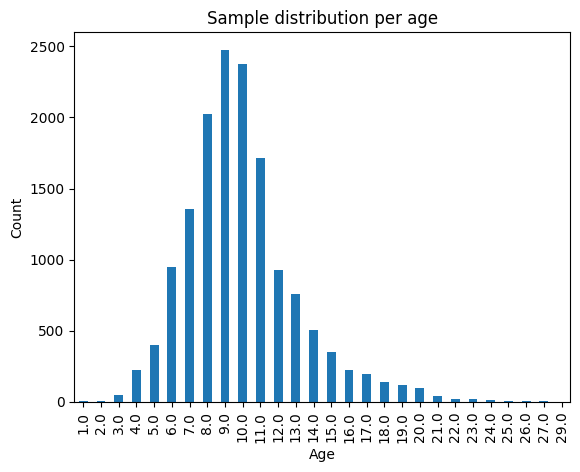

,id,Length,Diameter,Height,Weight,Shucked Weight,Viscera Weight,Shell Weight,Age,Shell_to_Weight,Meat_Ratio,Volume
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7499.500000,1.314114,1.021969,0.346207,23.207945,10.029359,5.011420,6.648089,9.922467,0.291468,0.431452,0.535877
std,4330.271354,0.289515,0.238842,0.090708,12.618130,5.600515,2.794041,3.566568,3.196259,0.036980,0.078943,0.299671
min,0.000000,0.275000,0.125000,0.000000,0.141747,0.070874,0.085048,0.085048,1.000000,0.135135,0.135593,0.000000
25%,3749.750000,1.150000,0.875000,0.287500,13.168343,5.669900,2.778251,3.827183,8.000000,0.266611,0.399546,0.295312
50%,7499.500000,1.375000,1.075000,0.362500,23.700182,9.893975,4.918638,6.803880,10.000000,0.288248,0.432273,0.543813
75%,11249.250000,1.525000,1.200000,0.412500,32.134158,13.947954,6.959802,9.071840,11.000000,0.312997,0.464234,0.749268
max,14999.000000,2.037500,1.950000,0.625000,78.797435,38.229301,18.228728,32.119983,29.000000,0.736192,4.691943,1.930500


In [4]:
# x axis : age
# y axis : count
# histogram showing age distribution
import matplotlib.pyplot as plt

train_set['Age'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Sample distribution per age')
plt.show()
train_set.describe()

On remarque que la plupart des crabes du jeu de données ont entre 5 et 15 ans, cela risque de rendre le modèle moins précis sur cette population

#### Créations des matrices
On crée les matrices et vecteurs pour l'évaluation du modèle sur le jeu de données d'entrainement
On prépare la prédiction sur le test en créant x_test

In [5]:
x_train = train_set.drop(columns=["id", "Age"])
x_train = pd.get_dummies(x_train, columns=["Sex"])
x_train = x_train.values

y_train = train_set["Age"]
y_train = y_train.values

x_test = test_set.drop(columns=["id"])
x_test = pd.get_dummies(x_test, columns=["Sex"])
x_test = x_test.values

X_train, X_val, y_train, y_val = train_test_split(
    x_train, y_train, test_size=0.2, random_state=42
)

print(f"Train : {X_train.shape[0]} exemples")
print(f"Val   : {X_val.shape[0]} exemples")

Train : 12000 exemples
Val   : 3000 exemples


In [6]:
from sklearn.utils import compute_sample_weight
model = Pipeline(    [
        ("scaler", StandardScaler()),
        ("regressor", LinearRegression()),
    ]
)

model.fit(X_train, y_train)
y_pred = model.predict(X_val)
mae = mean_absolute_error(y_val, y_pred)
print(f"MAE Locale : {mae:.4f}")

MAE Locale : 1.4185


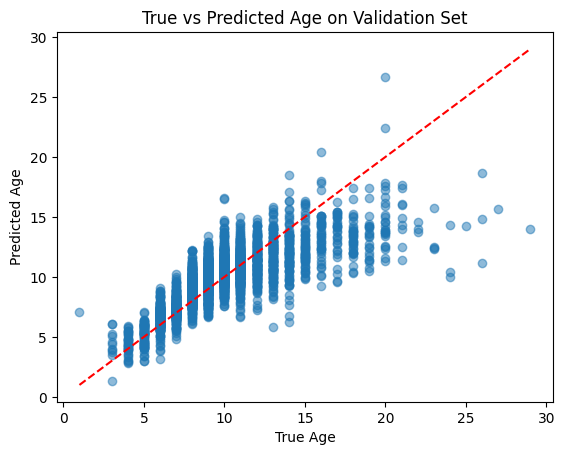

In [7]:
import matplotlib.pyplot as plt
plt.scatter(y_val, y_pred, alpha=0.5)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
plt.xlabel("True Age")
plt.ylabel("Predicted Age")
plt.title("True vs Predicted Age on Validation Set")
plt.show()

In [8]:
predictions = model.predict(x_test)
submission = pd.DataFrame({"id": test_set["id"], "Age": predictions})
submission.to_csv(r"./submission.csv", index=False)

Bilan du modèle de régression linéaire : meilleure performance que la régression arbre de décision

In [9]:
# import GradientBoostingRegressor
from sklearn.ensemble import GradientBoostingRegressor

model = GradientBoostingRegressor(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_val)
mae = mean_absolute_error(y_val, y_pred)
print(f"MAE Locale : {mae:.4f}")

MAE Locale : 1.3564


In [10]:
import numpy as np
from lightgbm import LGBMRegressor
import lightgbm as lgb

model = LGBMRegressor(
    n_estimators=800,
    learning_rate=0.01,
    max_depth=7,
    num_leaves=31,
    subsample=0.7,
    colsample_bytree=0.9,
    random_state=42
)
# Option: log-transform target
model.fit(X_train, np.log1p(y_train),
          eval_set=[(X_val, np.log1p(y_val))],
          callbacks=[lgb.early_stopping(50)])
y_pred = np.expm1(model.predict(X_val))
mae = mean_absolute_error(y_val, y_pred)
print(f"MAE: {mae}")

        

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001727 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2066
[LightGBM] [Info] Number of data points in the train set: 12000, number of used features: 13
[LightGBM] [Info] Start training from score 2.350553
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGB

/home/nono/efrei_ml_crabs/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [11]:
from xgboost import XGBRegressor
model = XGBRegressor(
        n_estimators=500,
    learning_rate=0.01,
    max_depth=7,
    subsample=0.7,
    colsample_bytree=0.9,
    random_state=42)
model.fit(X_train, np.log1p(y_train),
          eval_set=[(X_val, np.log1p(y_val))],)
y_pred = np.expm1(model.predict(X_val))
mae = mean_absolute_error(y_val, y_pred)
print(f"MAE: {mae}")

[0]	validation_0-rmse:0.28437
[1]	validation_0-rmse:0.28250
[2]	validation_0-rmse:0.28059
[3]	validation_0-rmse:0.27873
[4]	validation_0-rmse:0.27689
[5]	validation_0-rmse:0.27505
[6]	validation_0-rmse:0.27329
[7]	validation_0-rmse:0.27151
[8]	validation_0-rmse:0.26974
[9]	validation_0-rmse:0.26801
[10]	validation_0-rmse:0.26629
[11]	validation_0-rmse:0.26462
[12]	validation_0-rmse:0.26298
[13]	validation_0-rmse:0.26134
[14]	validation_0-rmse:0.25974
[15]	validation_0-rmse:0.25815
[16]	validation_0-rmse:0.25662
[17]	validation_0-rmse:0.25506
[18]	validation_0-rmse:0.25357
[19]	validation_0-rmse:0.25204
[20]	validation_0-rmse:0.25057
[21]	validation_0-rmse:0.24912
[22]	validation_0-rmse:0.24769
[23]	validation_0-rmse:0.24626
[24]	validation_0-rmse:0.24484
[25]	validation_0-rmse:0.24344
[26]	validation_0-rmse:0.24209
[27]	validation_0-rmse:0.24075
[28]	validation_0-rmse:0.23945
[29]	validation_0-rmse:0.23815
[30]	validation_0-rmse:0.23686
[31]	validation_0-rmse:0.23560
[32]	validation_0-